# Seasonal Patterns

This notebook analyzes recurring seasonal patterns in Rossmann store sales.

The analysis focuses on:
- Monthly seasonality
- Day-of-week seasonality
- Year-over-year sales patterns
- Recurring demand behavior

Understanding seasonality is important for selecting and building
appropriate forecasting models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/raw/train.csv")

train["Date"] = pd.to_datetime(train["Date"])

# Consider only open stores
open_sales = train[train["Open"] == 1].copy()

# Aggregate sales across stores by date
daily_sales = (
    open_sales
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

daily_sales.head()

/var/folders/vk/6pn68sk92z93wvsph2msbyvh0000gn/T/ipykernel_19092/2982384294.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [2]:
daily_sales["Month"] = daily_sales["Date"].dt.month

monthly_sales = (
    daily_sales
    .groupby("Month")["Sales"]
    .mean()
)

monthly_sales

Month
1     6.093857e+06
2     6.294457e+06
3     6.449805e+06
4     6.398837e+06
5     6.120949e+06
6     6.423475e+06
7     6.398486e+06
8     5.835342e+06
9     5.709502e+06
10    5.675463e+06
11    6.158315e+06
12    6.997277e+06
Name: Sales, dtype: float64

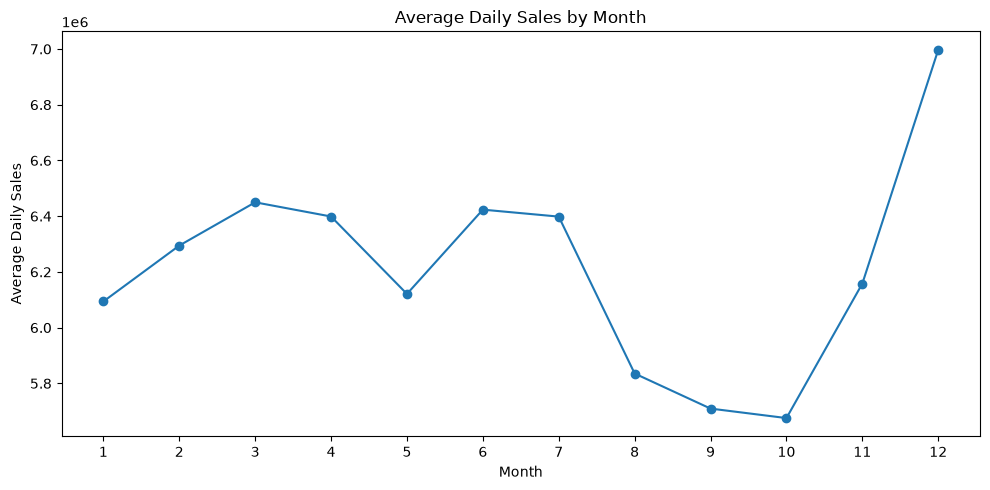

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [4]:
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek

day_sales = (
    daily_sales
    .groupby("DayOfWeek")["Sales"]
    .mean()
)

day_sales

DayOfWeek
0    8.434351e+06
1    7.558607e+06
2    7.073799e+06
3    6.749465e+06
4    7.263377e+06
5    6.315804e+06
6    2.205331e+05
Name: Sales, dtype: float64

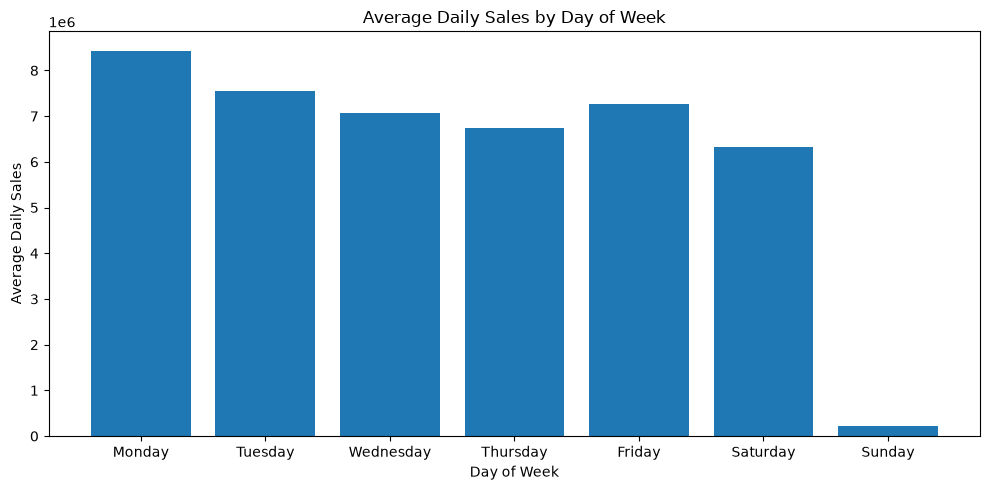

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_sales.index,
    day_sales.values
)

plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Sales")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.tight_layout()
plt.show()

In [6]:
daily_sales["Year"] = daily_sales["Date"].dt.year

yearly_sales = (
    daily_sales
    .groupby("Year")["Sales"]
    .mean()
)

yearly_sales

Year
2013    6.309250e+06
2014    5.974808e+06
2015    6.554244e+06
Name: Sales, dtype: float64

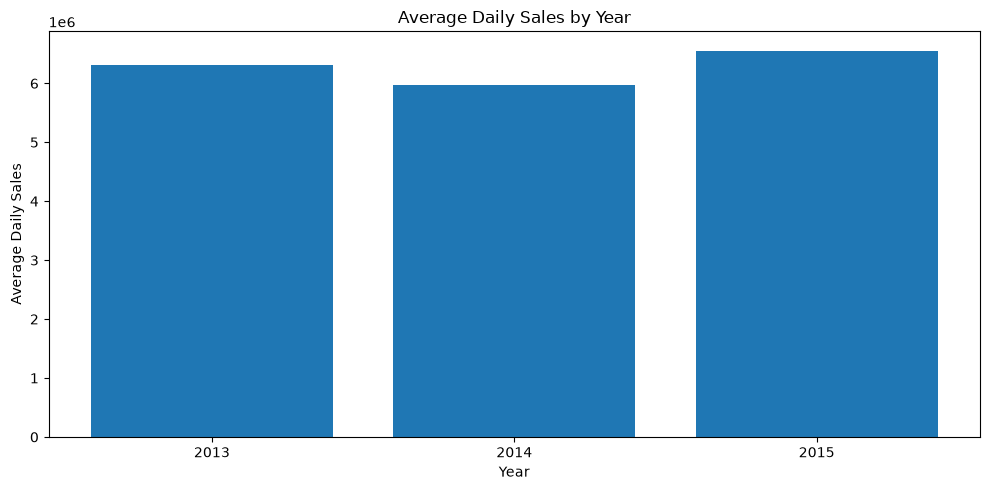

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Average Daily Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Daily Sales")

plt.tight_layout()
plt.show()

In [8]:
monthly_year_sales = (
    daily_sales
    .groupby(["Year", "Month"])["Sales"]
    .mean()
    .unstack()
)

monthly_year_sales

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2013,5.810716e+06,6.126224e+06,6.489689e+06,6.114381e+06,5.981002e+06,6.023412e+06,6.736899e+06,6.388475e+06,5.935132e+06,6.053624e+06,6.539031e+06,7.474534e+06
2014,6.056542e+06,6.390167e+06,6.226447e+06,6.484833e+06,6.280428e+06,6.334902e+06,5.609442e+06,5.282209e+06,5.483872e+06,5.297303e+06,5.777598e+06,6.520019e+06
2015,6.414314e+06,6.366981e+06,6.633280e+06,6.597296e+06,6.101416e+06,6.912112e+06,6.849117e+06,NaN,NaN,NaN,NaN,NaN


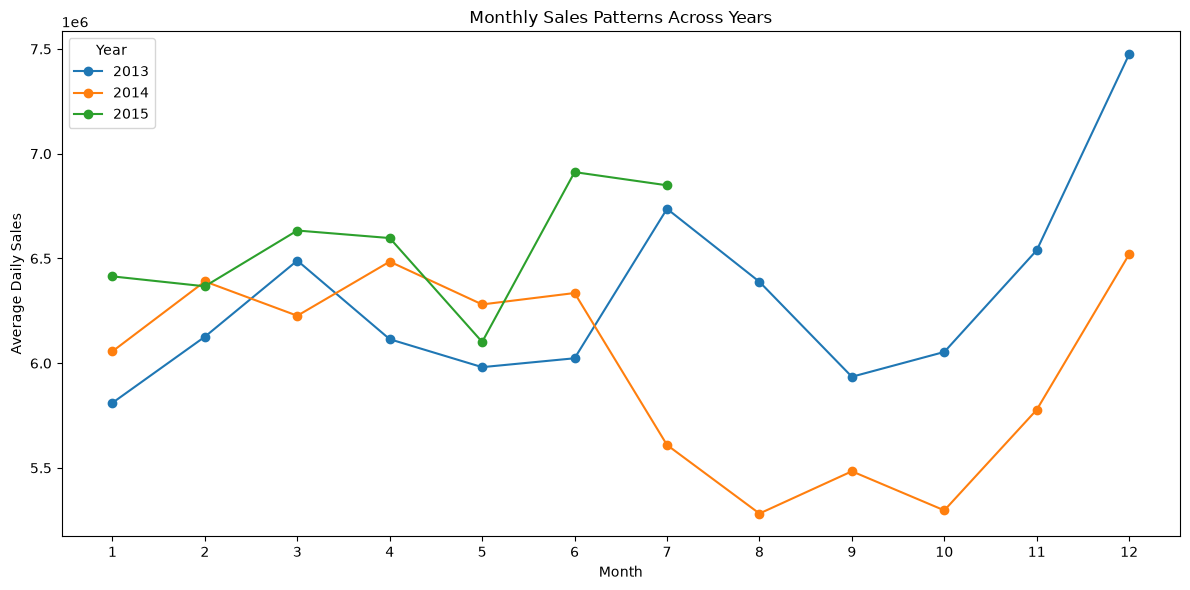

In [9]:
plt.figure(figsize=(12, 6))

for year in monthly_year_sales.index:
    plt.plot(
        monthly_year_sales.columns,
        monthly_year_sales.loc[year],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Sales Patterns Across Years")
plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.xticks(range(1, 13))
plt.legend(title="Year")

plt.tight_layout()
plt.show()

In [10]:
%pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

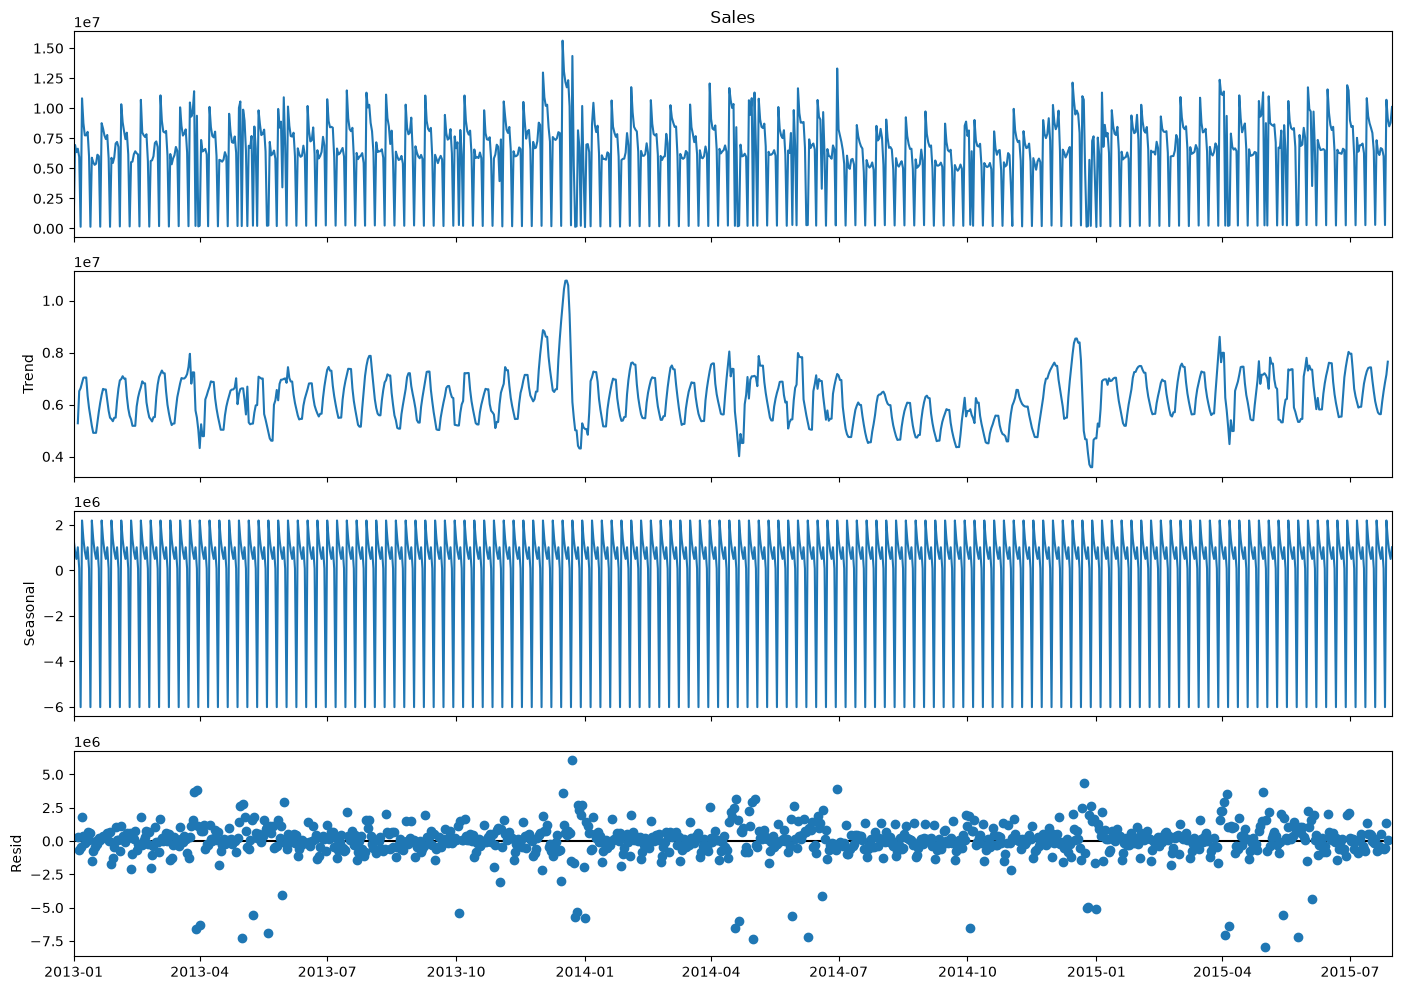

In [12]:
# Set Date as index
ts = daily_sales.set_index("Date")["Sales"]

# Perform seasonal decomposition
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

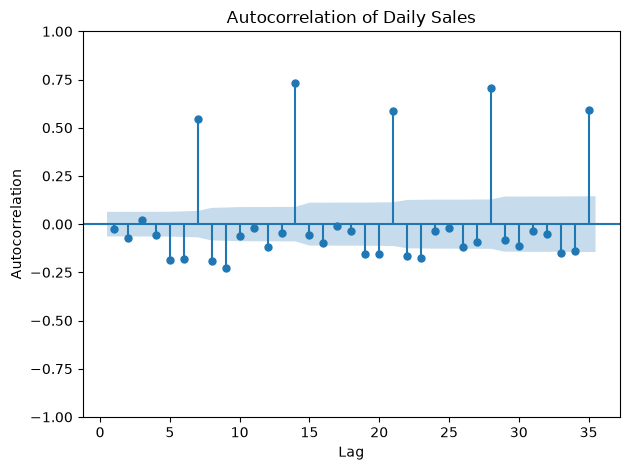

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))

plot_acf(
    daily_sales["Sales"],
    lags=35,
    zero=False
)

plt.title("Autocorrelation of Daily Sales")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

## Seasonal Pattern Findings

### Monthly Patterns
- Sales vary across different months.
- Sales generally decline during the late summer and autumn months.
- Sales increase again toward the end of the year.
- December shows particularly high average daily sales.

### Weekly Patterns
- A strong day-of-week pattern is present.
- Monday has the highest average sales among operating days.
- Sunday has extremely low sales because many stores are closed.

### Yearly Patterns
- Average daily sales vary across years.
- Sales were lower in 2014 compared with 2013 and 2015.
- 2015 shows an overall recovery in average daily sales.

### Seasonal Decomposition
- The decomposition confirms a strong repeating weekly seasonal component.
- The trend component shows changes in overall sales levels over time.
- Residuals contain unusual spikes and unexpected variations.

### Autocorrelation
- Strong autocorrelation peaks occur at lags 7, 14, 21, 28 and 35.
- This confirms a strong weekly seasonal pattern.
- Previous weeks' sales are useful for predicting future sales.

### Conclusion
The sales data contains clear weekly seasonality, along with longer-term trend changes and irregular variations. These patterns should be considered when building forecasting models.